## conditional Diffusion Training

## Plan 

1. Understand the intuition behind diffusion-based generation.  
2. Implement a small **Conditional Denoising Diffusion Probabilistic Model (DDPM)** in PyTorch.  
3. Train it on the MNIST dataset and visualise results.  
4. Compare it briefly to a pre-built model from Hugging Face Diffusers.

## Recap - Diffusion Models

Unlike GANs, which learn via competition, diffusion models learn by **gradually denoising data**.

1. **Forward Process:** Adds noise step-by-step to an image until it becomes pure noise.  
2. **Reverse Process:** Learns to remove noise — reconstructing clean samples.

If the model can learn to reverse this noise for each timestep, it can start from random noise and “paint” an image.

In our case, we’ll condition the denoiser on digit labels (0–9) to control which digit is drawn.

In [1]:
# Import core libraries 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os, sys



from model.diffusion import ConditionalUNet
from training.train_diffusion import train_diffusion, sample_images
from data_utils.dataloader import get_mnist_loaders
from utils.visualize import show_batch
from utils.checkpoint import load_checkpoint

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" Using device: {device}")


warnings.filterwarnings("ignore")

 Using device: cuda


###  Let’s configure a small diffusion system suitable for MNIST (28×28 grayscale).



In [6]:
# Hyperparameters
img_shape = (1, 28, 28)
num_classes = 10
timesteps = 1000   # number of diffusion steps
batch_size = 128
epochs = 40
lr = 1e-4

In [7]:
#ToDO: extract the data 
#Tip: Use the `get_mnist_loader` function in dataloader.py
train_loader, test_loader = get_mnist_loaders(batch_size=batch_size, diffusion=True)

In [8]:
imgs, labels = next(iter(train_loader))
imgs.shape

torch.Size([128, 1, 28, 28])

## Diffusion Model Architecture 

Our diffusion model will use a **U-Net** as the denoiser — a convolutional architecture that captures both local and global context.  
We’ll add:
- **Timestep embeddings** so the model knows “how noisy” the input is.
- **Label embeddings** for conditional generation.


### Training Loop

Our training objective is to predict the noise that was added at each timestep.  
We’ll use **Mean Squared Error (MSE)** between the predicted and actual noise.

In [9]:
# ToDo: 
     # 1. Instantiate Conditional Model
     # 2. Initiate training Loop
diffusion_model = ConditionalUNet().to(device)
diffusion_model

ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=

In [10]:
train_diffusion(diffusion_model, train_loader, device, num_classes, timesteps=timesteps, epochs=epochs, lr=lr)

Epoch 1/40: 100%|██████████| 469/469 [00:59<00:00,  7.86it/s, loss=0.044] 


Epoch 1 completed. Loss: 0.0440


Epoch 2/40: 100%|██████████| 469/469 [01:02<00:00,  7.52it/s, loss=0.0368]


Epoch 2 completed. Loss: 0.0368


Epoch 3/40: 100%|██████████| 469/469 [01:02<00:00,  7.55it/s, loss=0.0258]


...

Epoch 38 completed. Loss: 0.0216


Epoch 39/40: 100%|██████████| 469/469 [01:03<00:00,  7.43it/s, loss=0.0176]


Epoch 39 completed. Loss: 0.0176


Epoch 40/40: 100%|██████████| 469/469 [01:03<00:00,  7.42it/s, loss=0.0203]


Epoch 40 completed. Loss: 0.0203
Saved checkpoint: ../checkpoints/diffusion_unet_epoch40.pt
Saved checkpoint: ../checkpoints/diffusion_unet_epochfinal.pt


In [11]:
### notice we start to see the loss slowly decrease.  Unlike GANs, diffusion training is much more stable but typically slower to converge.

In [12]:

num_classes = 10
model = ConditionalUNet(num_classes=num_classes).to(device)

# load final trained weights
checkpoint_path = "../checkpoints/diffusion_unet_epochfinal.pt"
#checkpoint_path = "../checkpoints/diffusion_unet_epoch10.pt"
model = load_checkpoint(model, path=checkpoint_path, map_location=device)
model.eval()

Loaded model weights from ../checkpoints/diffusion_unet_epochfinal.pt


ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=

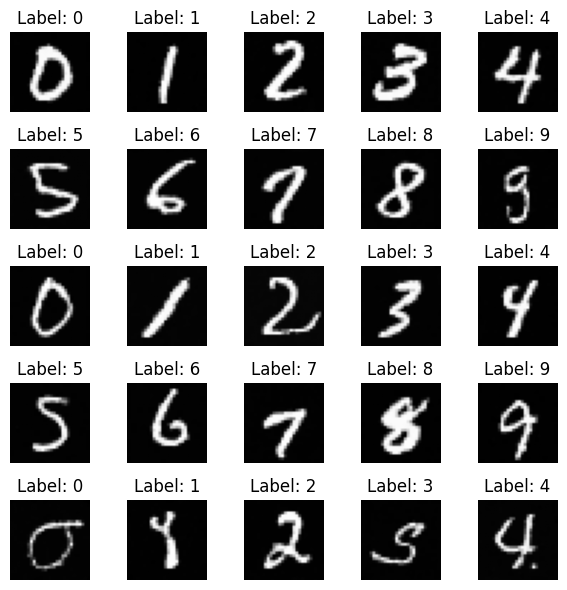

In [13]:
# sample images 

gen_imgs, labels = sample_images(model, device, num_samples=25, timesteps=1200, num_classes=num_classes)
show_batch(gen_imgs.to(device), labels.to(device), n=25)

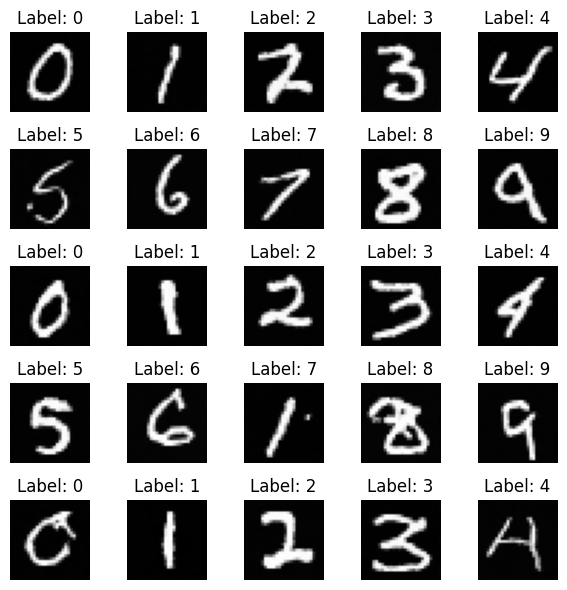

In [15]:
# sample images 

gen_imgs, labels = sample_images(model, device, num_samples=25, timesteps=1000, num_classes=num_classes)
show_batch(gen_imgs.to(device), labels.to(device), n=25)

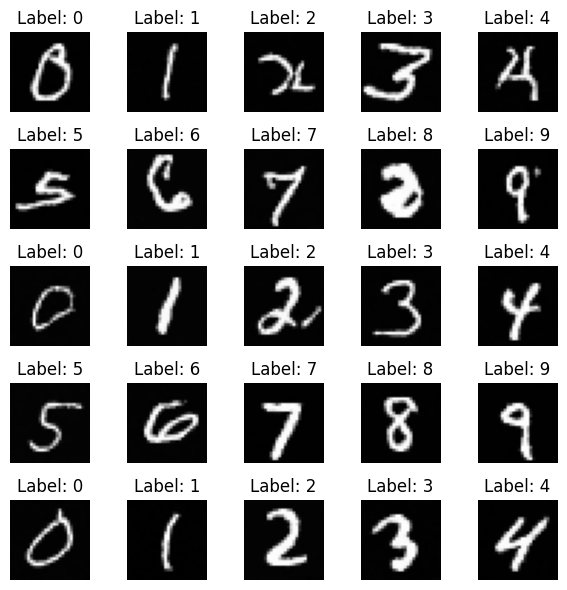

In [20]:
# sample images 

gen_imgs, labels = sample_images(model, device, num_samples=25, timesteps=1200, num_classes=num_classes)
show_batch(gen_imgs.to(device), labels.to(device), n=25)